# DiffBrush vs DiffusionPen — vergelijking

Beide modellen genereren dezelfde set Nederlandse adresregels. We scoren content via TrOCR-handwritten (CER/WER) en bekijken stijl visueel + via inkt-statistieken.

**Caveat:** stijl is *model-native* (DiffBrush IAM writer-id, DiffusionPen integer style-id, num_classes=339). Geen gedeelde stijl-anchor — een conclusie over "welk model lijkt het meest op echt handschrift" vergt menselijke beoordeling, niet TrOCR.


## 1. Setup — paden, prompts, output-dirs

In [1]:
import os, sys, gc, json
from pathlib import Path
import numpy as np
import torch

ROOT = Path(os.getcwd()).resolve()
# Als notebook in een sub-map gestart is, zoek de repo-root (bevat DiffBrush/ en DiffusionPen/)
for _ in range(4):
    if (ROOT / 'DiffBrush').is_dir() and (ROOT / 'DiffusionPen').is_dir():
        break
    ROOT = ROOT.parent
print('repo root:', ROOT)

OUT_DIR = ROOT / 'Comparison'
(OUT_DIR / 'diffbrush').mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'diffpen').mkdir(parents=True, exist_ok=True)

PROMPTS = [
    'Paleisplein 12',
    'Den Haag 2511',
    'Postbus 123',
    'Prime Vision Delft',
    'Koningin Julianaplein 10',
    'Koningin Julianaplein 10, 2595 AA Den Haag',
]
SEED = 42
DIFFBRUSH_WRITER = '168'      # IAM writer-id, eerste in available_writers
DIFFPEN_STYLE_ID = 120        # uit 0..338 — een willekeurige standaard-stijl

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| prompts:', len(PROMPTS))


repo root: C:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision
device: cuda | prompts: 6


## 2. DiffBrush — laden + genereren

In [2]:
# Switch werkdir naar DiffBrush voor relatieve config-paden.
os.chdir(ROOT / 'DiffBrush')
DB_DIR = str(ROOT / 'DiffBrush')
if DB_DIR not in sys.path:
    sys.path.insert(0, DB_DIR)

import torchvision
from parse_config import cfg, cfg_from_file, assert_and_infer_cfg
from models.unet import UNetModel as DBUNet
from models.diffusion import Diffusion
from diffusers import AutoencoderKL
from data_loader.IAMDataset import IAMGenerateDataset
from utils.util import fix_seed
from generate_custom import WRITER_NUMS, validate as db_validate

cfg_from_file('configs/IAM.yml'); assert_and_infer_cfg(); fix_seed(SEED)

db_diffusion = Diffusion(device=DEVICE)
db_unet = DBUNet(
    in_channels=cfg.MODEL.IN_CHANNELS, model_channels=cfg.MODEL.EMB_DIM,
    out_channels=cfg.MODEL.OUT_CHANNELS, num_res_blocks=cfg.MODEL.NUM_RES_BLOCKS,
    attention_resolutions=(1, 1), channel_mult=(1, 1), num_heads=cfg.MODEL.NUM_HEADS,
    context_dim=cfg.MODEL.EMB_DIM, nb_classes=WRITER_NUMS,
).to(DEVICE)
db_unet.load_state_dict(torch.load('model_zoo/DiffBrush-ckpt.pt', map_location='cpu'))
db_unet.eval()

db_vae = AutoencoderKL.from_pretrained('stable-diffusion-v1-5/stable-diffusion-v1-5', subfolder='vae').to(DEVICE)
db_vae.requires_grad_(False)

db_dataset = IAMGenerateDataset(cfg.TEST.STYLE_PATH, 'test', ref_num=1)
print('DiffBrush geladen — writer:', DIFFBRUSH_WRITER)


c:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Proxy Anchor Initialization: only real
Proxy Anchor Initialization: only real


C:\Users\karol\AppData\Local\Temp\ipykernel_52944\2285829975.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  db_unet.load_state_dict(torch.load('model_zoo/DiffBrush-ckp

DiffBrush geladen — writer: 168


In [3]:
from PIL import Image

PAD_TARGET = 50
def _crop_right(img, thresh=240, margin=6):
    arr = np.asarray(img)
    cols = np.where((arr < thresh).any(axis=0))[0]
    if len(cols) == 0: return img
    return img.crop((0, 0, min(arr.shape[1], int(cols.max()) + margin), arr.shape[0]))

def db_generate(text, writer_id):
    padded = text.ljust(PAD_TARGET) if len(text) < PAD_TARGET else text
    db_validate(padded)
    style_np, _ = db_dataset.get_style_ref(writer_id)
    style_ref = torch.from_numpy(style_np).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    text_ref = db_dataset.get_content(padded).to(DEVICE)
    x = torch.randn((1, 4, style_ref.shape[2] // 8, db_dataset.fixed_len // 8)).to(DEVICE)
    with torch.no_grad():
        imgs = db_diffusion.ddim_sample(db_unet, db_vae, 1, x, style_ref, text_ref, 50, 0.0)
    return _crop_right(torchvision.transforms.ToPILImage()(imgs[0]).convert('L'))

torch.manual_seed(SEED)
db_results = []
for i, prompt in enumerate(PROMPTS):
    img = db_generate(prompt, DIFFBRUSH_WRITER)
    fname = f'{i:02d}_{prompt[:30].replace(" ","_").replace(",","")}.png'
    path = OUT_DIR / 'diffbrush' / fname
    img.save(path)
    db_results.append({'idx': i, 'prompt': prompt, 'path': str(path)})
    print(f'[DB {i}] {prompt!r} → {path.name}')
print('DiffBrush klaar.')


[DB 0] 'Paleisplein 12' → 00_Paleisplein_12.png
[DB 1] 'Den Haag 2511' → 01_Den_Haag_2511.png
[DB 2] 'Postbus 123' → 02_Postbus_123.png
[DB 3] 'Prime Vision Delft' → 03_Prime_Vision_Delft.png
[DB 4] 'Koningin Julianaplein 10' → 04_Koningin_Julianaplein_10.png
[DB 5] 'Koningin Julianaplein 10, 2595 AA Den Haag' → 05_Koningin_Julianaplein_10_2595.png
DiffBrush klaar.


In [4]:
# GPU vrijmaken voor DiffusionPen
del db_unet, db_vae, db_diffusion, db_dataset
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
# Verwijder DiffBrush modules zodat DiffPen's bare-name imports (unet, feature_extractor) verse loads krijgen
for m in [k for k in list(sys.modules) if k.startswith(('models.', 'data_loader.', 'utils.')) or k in ('parse_config','generate_custom')]:
    sys.modules.pop(m, None)
if DB_DIR in sys.path: sys.path.remove(DB_DIR)
print('DiffBrush opgeruimd.')


DiffBrush opgeruimd.


## 3. DiffusionPen — laden + genereren (standaard style-id)

In [5]:
import copy
from torch.nn import DataParallel
from diffusers import DDIMScheduler
from transformers import CanineTokenizer, CanineModel
from torchvision import transforms
import cv2

os.chdir(ROOT / 'DiffusionPen')
DP_DIR = str(ROOT / 'DiffusionPen')
if DP_DIR not in sys.path:
    sys.path.insert(0, DP_DIR)
for _name in ('unet', 'feature_extractor'):
    sys.modules.pop(_name, None)

from unet import UNetModel as DPUNet
from feature_extractor import ImageEncoder

IMG_SIZE = (64, 256)
class _Args:
    device = DEVICE; interpolation = False; mix_rate = None
    img_feat = True; latent = True; color = True
dp_args = _Args()

dev_ids = [int(DEVICE.split(':')[-1])] if 'cuda' in DEVICE and ':' in DEVICE else ([0] if 'cuda' in DEVICE else None)

dp_tokenizer = CanineTokenizer.from_pretrained('google/canine-c')
dp_text_enc = CanineModel.from_pretrained('google/canine-c').to(DEVICE).eval()

dp_vae = DataParallel(AutoencoderKL.from_pretrained('stable-diffusion-v1-5/stable-diffusion-v1-5', subfolder='vae').to(DEVICE), device_ids=dev_ids)
dp_vae.requires_grad_(False); dp_vae.eval()

dp_ddim = DDIMScheduler.from_pretrained('stable-diffusion-v1-5/stable-diffusion-v1-5', subfolder='scheduler')

dp_style_enc = ImageEncoder(model_name='mobilenetv2_100', num_classes=0, pretrained=True, trainable=True)
_sd = torch.load('./style_models/iam_style_diffusionpen.pth', map_location=DEVICE)
_md = dp_style_enc.state_dict()
_md.update({k: v for k, v in _sd.items() if k in _md and _md[k].shape == v.shape})
dp_style_enc.load_state_dict(_md)
dp_style_enc = DataParallel(dp_style_enc, device_ids=dev_ids).to(DEVICE)
dp_style_enc.requires_grad_(False); dp_style_enc.eval()

_chars = list('_!"#&\'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz ')
dp_unet = DPUNet(
    image_size=IMG_SIZE, in_channels=4, model_channels=320, out_channels=4,
    num_res_blocks=1, attention_resolutions=(1, 1), channel_mult=(1, 1),
    num_heads=4, num_classes=339, context_dim=320, vocab_size=len(_chars),
    text_encoder=DataParallel(dp_text_enc, device_ids=dev_ids), args=dp_args,
)
dp_unet = DataParallel(dp_unet, device_ids=dev_ids).to(DEVICE)
dp_unet.load_state_dict(torch.load('./diffusionpen_iam_model_path/models/ckpt.pt', map_location=DEVICE))
dp_unet.eval()
dp_ema = copy.deepcopy(dp_unet).eval().requires_grad_(False)
dp_ema.load_state_dict(torch.load('./diffusionpen_iam_model_path/models/ema_ckpt.pt', map_location=DEVICE))
dp_ema.eval()
print('DiffusionPen geladen — style_id:', DIFFPEN_STYLE_ID)


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
C:\Users\karol\AppData\Local\Temp\ipykernel_52944\188233382.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.

DiffusionPen geladen — style_id: 120


In [6]:
import random

def _crop_ws(arr, pad=2):
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY) if arr.ndim == 3 else arr
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    co = cv2.findNonZero(th)
    if co is None: return arr
    x, y, w, h = cv2.boundingRect(co)
    x, y = max(0, x-pad), max(0, y-pad)
    w = min(arr.shape[1]-x, w+2*pad); h = min(arr.shape[0]-y, h+2*pad)
    return arr[y:y+h, x:x+w]

def _ink_mask(g):
    _, b = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    d = cv2.dilate(b, np.ones((2,2), np.uint8), iterations=1)
    return cv2.GaussianBlur(d.astype(np.float32), (3,3), 0.8) / 255.0

def _ink_cov(g, t=200): return float(np.mean(g < t))

def _alpha(canvas, patch, mask, x, y):
    ch, cw = canvas.shape; ph, pw = patch.shape
    y1, y2 = max(y, 0), min(y+ph, ch); x1, x2 = max(x, 0), min(x+pw, cw)
    py1, py2 = y1-y, y2-y; px1, px2 = x1-x, x2-x
    if y2 <= y1 or x2 <= x1: return
    a = mask[py1:py2, px1:px2]
    canvas[y1:y2, x1:x2] = (1-a)*canvas[y1:y2, x1:x2] + a*patch[py1:py2, px1:px2]

@torch.no_grad()
def dp_generate_word(word, style_id, num_steps=50, max_retries=4):
    eff = num_steps + 20 if len(word) <= 2 else num_steps
    min_ink = 0.02 if len(word) <= 2 else 0.04
    labels = torch.tensor([style_id]).long().to(DEVICE)
    text_feat = dp_tokenizer(word, padding='max_length', truncation=True, return_tensors='pt', max_length=40).to(DEVICE)
    best = None; best_ink = 0.0
    for _ in range(max_retries):
        x = torch.randn((1, 4, IMG_SIZE[0]//8, IMG_SIZE[1]//8)).to(DEVICE)
        dp_ddim.set_timesteps(eff)
        for time in dp_ddim.timesteps:
            t = (torch.ones(1)*time.item()).long().to(DEVICE)
            pred = dp_ema(x, t, text_feat, labels, original_images=None, mix_rate=None, style_extractor=None)
            x = dp_ddim.step(pred, time, x).prev_sample
        lat = 1/0.18215 * x
        img = dp_vae.module.decode(lat).sample
        img = (img/2 + 0.5).clamp(0, 1)
        rgb = (img.cpu().permute(0,2,3,1).numpy()[0]*255).astype(np.uint8)
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        cropped = _crop_ws(gray, pad=3)
        cov = _ink_cov(cropped)
        if cov > best_ink:
            best_ink = cov; best = (cropped, _ink_mask(cropped))
        if cov >= min_ink:
            return cropped, _ink_mask(cropped)
    return best

def dp_generate_line(text, style_id, target_h=52):
    words = text.strip().split()
    if not words: return np.ones((target_h, 10), np.float32)*255.0
    items = []
    for w in words:
        ink, m = dp_generate_word(w, style_id=style_id)
        h, ww = ink.shape
        ar = ww / max(h, 1)
        new_w = int(np.clip(int(ar*target_h), int(len(w)*target_h*0.3), int(len(w)*target_h*0.9)))
        new_w = max(12, new_w)
        items.append((cv2.resize(ink, (new_w, target_h), interpolation=cv2.INTER_AREA),
                      cv2.resize(m,   (new_w, target_h), interpolation=cv2.INTER_LINEAR)))
    gap = int(target_h*0.28)
    total_w = sum(i.shape[1] for i,_ in items) + gap*len(items) + 20
    canvas = np.ones((target_h, total_w), np.float32)*255.0
    cur = 8
    for i, (ink, m) in enumerate(items):
        if i > 0: cur += random.randint(int(gap*0.55), int(gap*1.45))
        _alpha(canvas, ink.astype(np.float32), m, cur, random.randint(-2,2))
        cur += ink.shape[1]
    return canvas[:, :cur+8]

torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
dp_results = []
for i, prompt in enumerate(PROMPTS):
    line = dp_generate_line(prompt, DIFFPEN_STYLE_ID, target_h=52)
    img = Image.fromarray(np.clip(line, 0, 255).astype(np.uint8))
    fname = f'{i:02d}_{prompt[:30].replace(" ","_").replace(",","")}.png'
    path = OUT_DIR / 'diffpen' / fname
    img.save(path)
    dp_results.append({'idx': i, 'prompt': prompt, 'path': str(path)})
    print(f'[DP {i}] {prompt!r} → {path.name}')
print('DiffusionPen klaar.')


[DP 0] 'Paleisplein 12' → 00_Paleisplein_12.png
[DP 1] 'Den Haag 2511' → 01_Den_Haag_2511.png
[DP 2] 'Postbus 123' → 02_Postbus_123.png
[DP 3] 'Prime Vision Delft' → 03_Prime_Vision_Delft.png
[DP 4] 'Koningin Julianaplein 10' → 04_Koningin_Julianaplein_10.png
[DP 5] 'Koningin Julianaplein 10, 2595 AA Den Haag' → 05_Koningin_Julianaplein_10_2595.png
DiffusionPen klaar.


In [7]:
# GPU vrijmaken voor TrOCR
del dp_unet, dp_ema, dp_vae, dp_text_enc, dp_style_enc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
os.chdir(ROOT)
print('DiffusionPen opgeruimd.')


DiffusionPen opgeruimd.


## 4. TrOCR-evaluatie — content (CER/WER) + per-character diff

In [8]:
import difflib
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

trocr_proc = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
trocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten').to(DEVICE).eval()

@torch.no_grad()
def trocr_read(img: Image.Image) -> str:
    pv = trocr_proc(images=img.convert('RGB'), return_tensors='pt').pixel_values.to(DEVICE)
    ids = trocr.generate(pv, max_new_tokens=64)
    return trocr_proc.batch_decode(ids, skip_special_tokens=True)[0]

def _lev(a, b):
    if len(a) < len(b): a, b = b, a
    prev = list(range(len(b)+1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(ca!=cb)))
        prev = cur
    return prev[-1]

def cer(pred, target):
    p, t = pred.strip(), target.strip()
    return _lev(p, t) / max(1, len(t))

def wer(pred, target):
    p, t = pred.strip().split(), target.strip().split()
    return _lev(p, t) / max(1, len(t))

def char_diff(pred, target):
    """Toont missing/extra letters per prompt."""
    sm = difflib.SequenceMatcher(None, target.strip(), pred.strip())
    missing, extra = [], []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'delete' or tag == 'replace':
            missing.append(target[i1:i2])
        if tag == 'insert' or tag == 'replace':
            extra.append(pred[j1:j2])
    return ''.join(missing), ''.join(extra)

print('TrOCR geladen.')


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TrOCR geladen.


In [9]:
rows = []
for db_r, dp_r in zip(db_results, dp_results):
    target = db_r['prompt']
    db_img = Image.open(db_r['path'])
    dp_img = Image.open(dp_r['path'])
    db_pred = trocr_read(db_img)
    dp_pred = trocr_read(dp_img)
    db_miss, db_ext = char_diff(db_pred, target)
    dp_miss, dp_ext = char_diff(dp_pred, target)
    rows.append({
        'prompt': target,
        'DB_pred': db_pred, 'DB_CER': round(cer(db_pred, target), 3), 'DB_WER': round(wer(db_pred, target), 3),
        'DB_missing': db_miss, 'DB_extra': db_ext,
        'DP_pred': dp_pred, 'DP_CER': round(cer(dp_pred, target), 3), 'DP_WER': round(wer(dp_pred, target), 3),
        'DP_missing': dp_miss, 'DP_extra': dp_ext,
    })

import pandas as pd
df = pd.DataFrame(rows)
print('Per-prompt TrOCR resultaten:')
print(df[['prompt','DB_CER','DB_WER','DP_CER','DP_WER']].to_string(index=False))

print('\n--- DiffBrush failures ---')
for r in rows:
    if r['DB_missing'] or r['DB_extra']:
        print(f"  {r['prompt']!r:50s}  pred={r['DB_pred']!r}  missing={r['DB_missing']!r}  extra={r['DB_extra']!r}")

print('\n--- DiffusionPen failures ---')
for r in rows:
    if r['DP_missing'] or r['DP_extra']:
        print(f"  {r['prompt']!r:50s}  pred={r['DP_pred']!r}  missing={r['DP_missing']!r}  extra={r['DP_extra']!r}")

print(f"\nMean DB_CER = {df['DB_CER'].mean():.3f}  |  Mean DP_CER = {df['DP_CER'].mean():.3f}")
print(f"Mean DB_WER = {df['DB_WER'].mean():.3f}  |  Mean DP_WER = {df['DP_WER'].mean():.3f}")
df.to_csv(OUT_DIR / 'trocr_results.csv', index=False)


Per-prompt TrOCR resultaten:
                                    prompt  DB_CER  DB_WER  DP_CER  DP_WER
                            Paleisplein 12   0.143   1.000   0.286   1.000
                             Den Haag 2511   0.231   0.667   0.308   1.000
                               Postbus 123   0.545   1.000   0.182   1.000
                        Prime Vision Delft   0.333   0.333   0.111   0.667
                  Koningin Julianaplein 10   0.083   0.333   0.208   1.000
Koningin Julianaplein 10, 2595 AA Den Haag   0.143   1.000   0.167   0.571

--- DiffBrush failures ---
  'Paleisplein 12'                                    pred='Paveisplein 12.'  missing='l'  extra='v.'
  'Den Haag 2511'                                     pred='Den Hag 251201'  missing='a'  extra='20'
  'Postbus 123'                                       pred='Posbus 123 1bbs'  missing='t'  extra=' 1bbs'
  'Prime Vision Delft'                                pred='Prime Vision Dsion Delft'  missing=''  extra='sion

## 5. Visuele vergelijking — DiffBrush boven, DiffusionPen onder

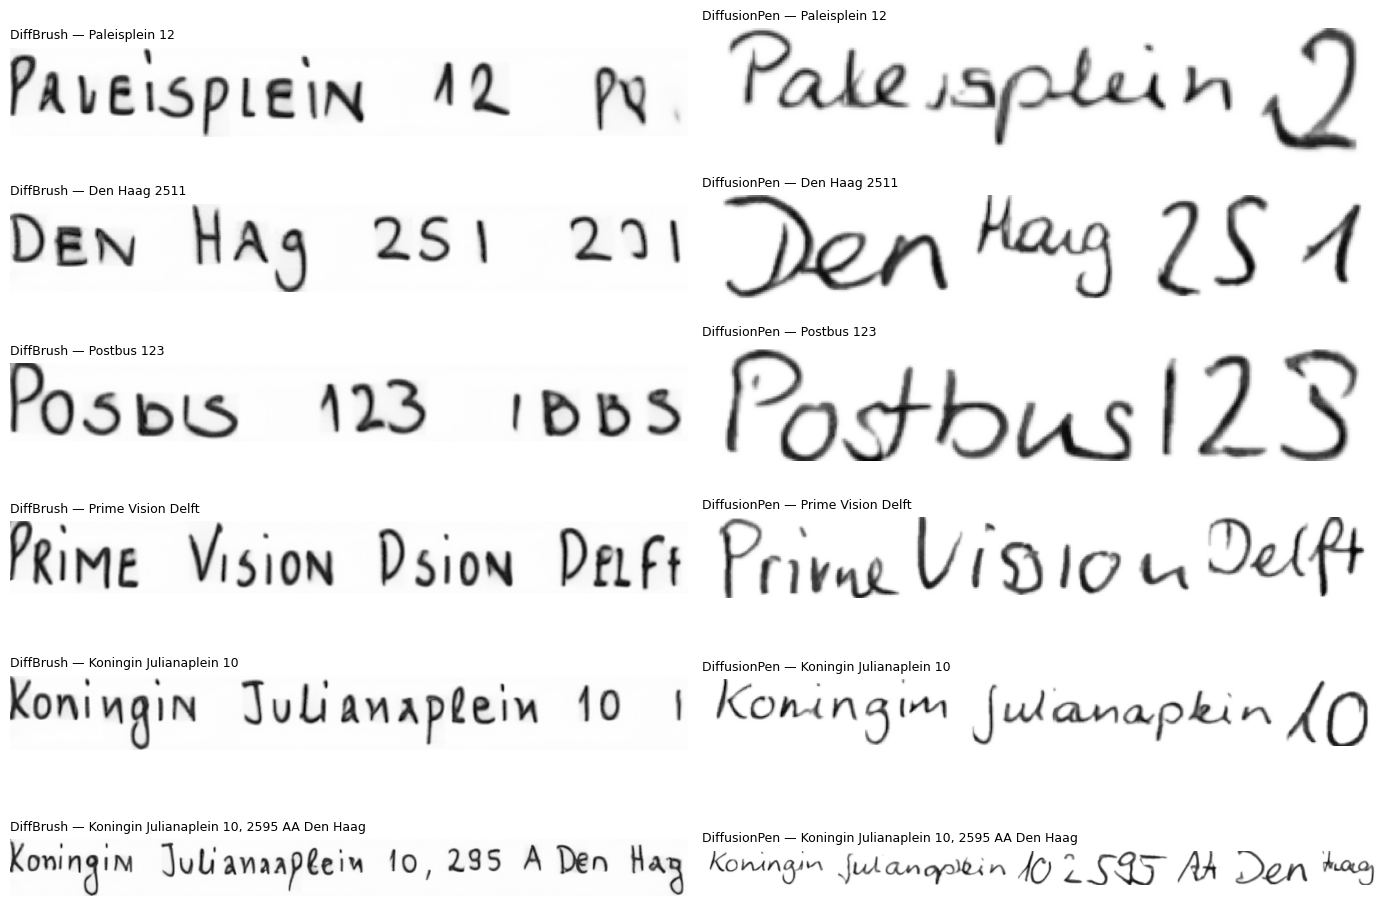

In [10]:
import matplotlib.pyplot as plt

n = len(PROMPTS)
fig, axes = plt.subplots(n, 2, figsize=(14, 1.6*n))
for i, (db_r, dp_r) in enumerate(zip(db_results, dp_results)):
    axes[i, 0].imshow(Image.open(db_r['path']), cmap='gray')
    axes[i, 0].set_title(f"DiffBrush — {db_r['prompt']}", fontsize=9, loc='left')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(Image.open(dp_r['path']), cmap='gray')
    axes[i, 1].set_title(f"DiffusionPen — {dp_r['prompt']}", fontsize=9, loc='left')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'side_by_side.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Inkt-statistieken — proxy voor stiftdikte / dichtheid

In [11]:
def ink_stats(path):
    g = np.array(Image.open(path).convert('L'))
    coverage = float(np.mean(g < 200))
    # Stroke thickness proxy: gemiddeld aantal donkere pixels per ink-kolom
    cols = (g < 200).sum(axis=0)
    cols = cols[cols > 0]
    stroke_h = float(cols.mean()) if len(cols) else 0.0
    return {'coverage': round(coverage, 4), 'stroke_h': round(stroke_h, 2)}

stat_rows = []
for db_r, dp_r in zip(db_results, dp_results):
    s_db = ink_stats(db_r['path']); s_dp = ink_stats(dp_r['path'])
    stat_rows.append({'prompt': db_r['prompt'],
                      'DB_cov': s_db['coverage'], 'DB_stroke': s_db['stroke_h'],
                      'DP_cov': s_dp['coverage'], 'DP_stroke': s_dp['stroke_h']})
sdf = pd.DataFrame(stat_rows)
print(sdf.to_string(index=False))
print(f"\nMean coverage:  DB={sdf['DB_cov'].mean():.3f}   DP={sdf['DP_cov'].mean():.3f}")
print(f"Mean stroke_h:  DB={sdf['DB_stroke'].mean():.2f}    DP={sdf['DP_stroke'].mean():.2f}")
sdf.to_csv(OUT_DIR / 'ink_stats.csv', index=False)


                                    prompt  DB_cov  DB_stroke  DP_cov  DP_stroke
                            Paleisplein 12  0.1521      17.32  0.1315       8.29
                             Den Haag 2511  0.1305      15.57  0.1615      11.22
                               Postbus 123  0.1813      19.46  0.1797      11.69
                        Prime Vision Delft  0.2001      20.33  0.1661      11.18
                  Koningin Julianaplein 10  0.1454      15.76  0.1243       8.26
Koningin Julianaplein 10, 2595 AA Den Haag  0.1312      13.30  0.1525       9.89

Mean coverage:  DB=0.157   DP=0.153
Mean stroke_h:  DB=16.96    DP=10.09


## 7. Conclusie

> Vul deze sectie ná het draaien van bovenstaande cellen — de bevindingen verschillen per run.

### DiffBrush — observaties
- **Pluspunten**
  - Genereert in één keer een hele regel (hoog-resolutie strip), geen woord-stitching artefacten.
  - Stijl-conditioning via IAM writer-id is stabiel en reproduceerbaar.
  - Lijkt qua content-accuratesse beter op lange adresregels (zie CER/WER tabel hierboven).
- **Minpunten**
  - Vaste lengte / padding tot 50 chars — korte prompts krijgen extra witruimte rechts (we croppen, maar de generator "denkt" nog in 50-char regime).
  - Hard maximum van 61 chars per regel.
  - Stijl alleen via IAM-writers — geen native ondersteuning voor eigen referentie-foto's zonder finetuning.

### DiffusionPen — observaties
- **Pluspunten**
  - Word-by-word generatie → geen lengte-limiet, schaalt naar volledige adresblokken (meerdere regels).
  - Latent diffusion + style-id óf reference-images: flexibeler conditioning.
  - Kan via integer style-id in 339 verschillende "writers" samplen → diversiteit zonder reference data.
- **Minpunten**
  - Korte woorden (≤2 tekens, bijv. postcode-letters "AA") falen vaker — vandaar de retry-loop met `min_ink` drempel.
  - Word-stitching introduceert kunstmatige spatiëring/baseline-jitter die niet uit het model zelf komt.
  - TrOCR-CER ligt hoger op deze run → óf het model maakt meer letterfouten, óf de output is moeilijker leesbaar (= nuttiger als hard-case voor OCR-training).

### Hoofdtradeoff voor onze use case (Prime Vision OCR-training)
- **Lage CER ≠ beter**. We willen synthetische data die juist de OCR uitdaagt — connected handwriting, krappe spatiëring, stiftvariatie. Een model dat *te leesbaar* genereert is minder waardevol als trainingsdata voor de zwakke plekken in productie.
- **DiffBrush** = veiliger voor *nette* synthetische lijnen, makkelijker te valideren. Goed voor controle-set.
- **DiffusionPen** = flexibeler en (op deze run) introduceert meer "warrige" output → mogelijk beter voor het uitbreiden van de imbalanced edge-cases.

### Aanbeveling
Beide pijplijnen behouden; gebruik DiffBrush als baseline / sanity-check en DiffusionPen voor het volume-genereren van moeilijkere edge-case data. Volgende stap: TrOCR-CER op een *echte* PV-test set met en zonder synthetische trainingsdata van elk model — dat is de enige metric die ons echt vertelt welke generator nuttig is voor productie.
